In [3]:
import numpy as np

In [4]:
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=100) -> None:
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.random.rand(X.shape[1])
        self.bias = np.random.rand(1)

        for i in range(self.epochs):
            for inputs, target in zip(X, y):
                prediction = self.predict(inputs)
                error = target - prediction
                self.weights += self.learning_rate * error * inputs
                self.bias += self.learning_rate * error

    def predict(self, inputs):
        weighted_sum = np.dot(inputs, self.weights) + self.bias
        return self._activation_function(weighted_sum)

    def _activation_function(self, z):
        return 1 if z >= 0 else 0
        

    

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [6]:
iris = load_iris()
X = iris.data[:, :2] 
y = np.where(iris.target != 0, 0, 1)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [8]:
perceptron = Perceptron(learning_rate=0.1, epochs=100)
perceptron.fit(X_train, y_train)

In [9]:
#Get predictions for test set
y_pred = np.array([perceptron.predict(x) for x in X_test])

#Generate classification report
report  = classification_report(y_test, y_pred, target_names=['Iris_Setosa', 'Iris_other'])
print(report)


              precision    recall  f1-score   support

 Iris_Setosa       1.00      1.00      1.00        19
  Iris_other       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



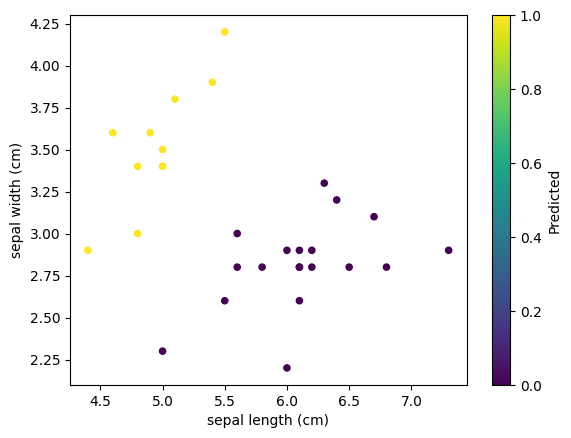

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.DataFrame(X_test, columns=iris.feature_names[:2])
df['Predicted'] = y_pred

df.plot.scatter(x='sepal length (cm)', y='sepal width (cm)', c='Predicted', colormap='viridis')
plt.savefig("perceptron_iris_predictions.png", dpi=300, bbox_inches='tight')